# Customer Intelligence System: Classification, Ensemble & Clustering

This notebook builds a country-level customer intelligence system for a humanitarian NGO deciding where to direct aid. Countries are grouped using clustering, the groups are turned into a development tier label, and tuned Random Forest and XGBoost classifiers are then trained to predict that tier directly from a country's socio-economic profile.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

## 2. Load the Dataset

In [2]:
try:
    df = pd.read_csv("Country-data.csv")
except FileNotFoundError:
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Data Overview

In [3]:
print(df.shape)
df.info()

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 4. Exploratory Data Analysis

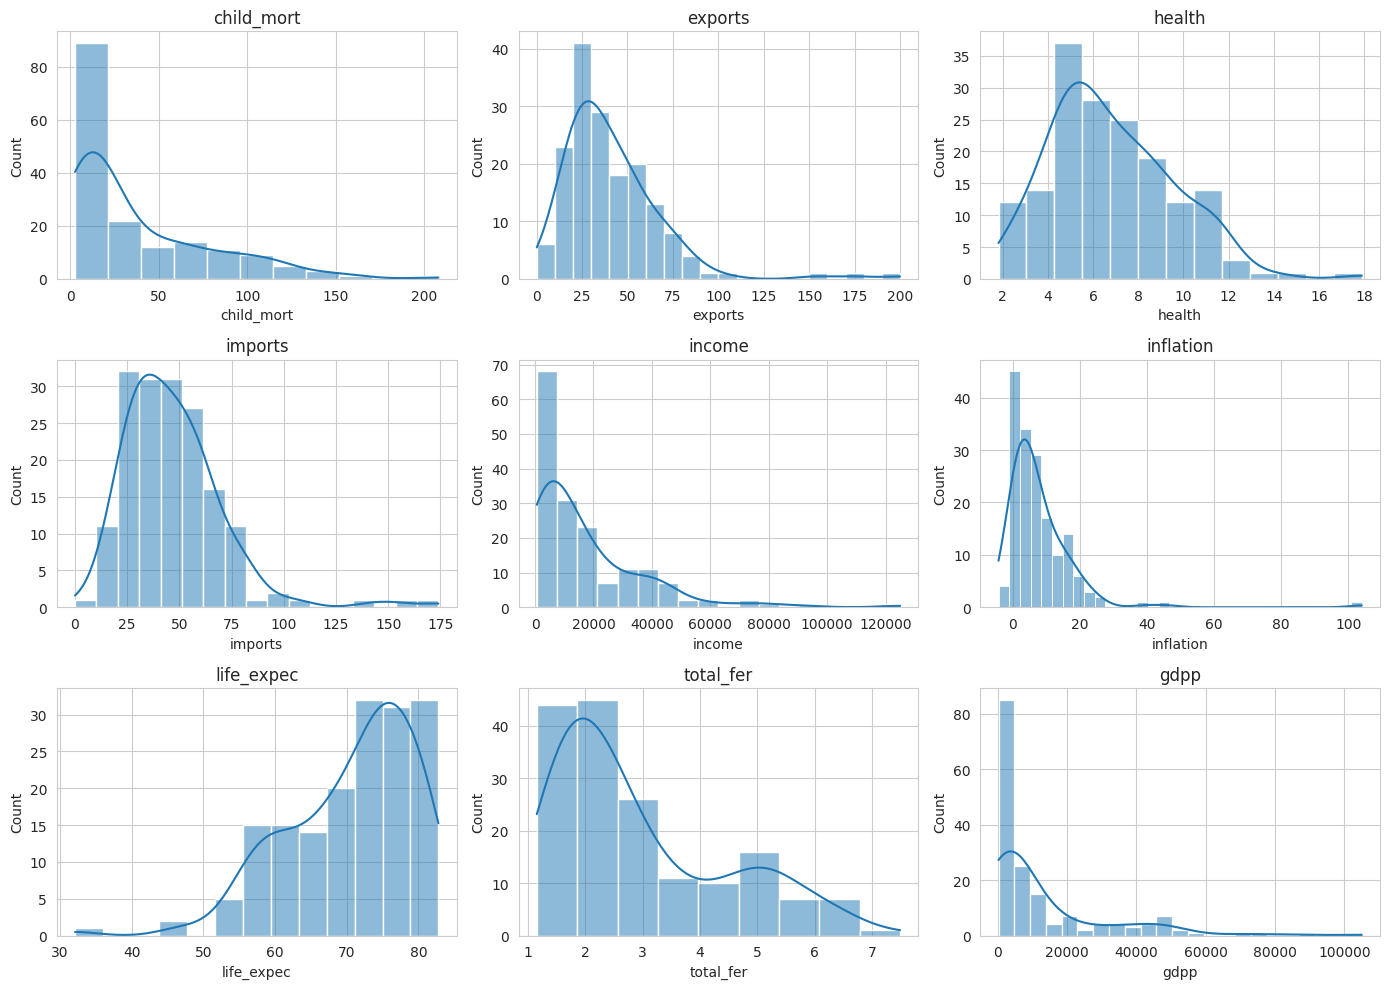

In [6]:
numeric_cols = df.columns.drop("country")
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

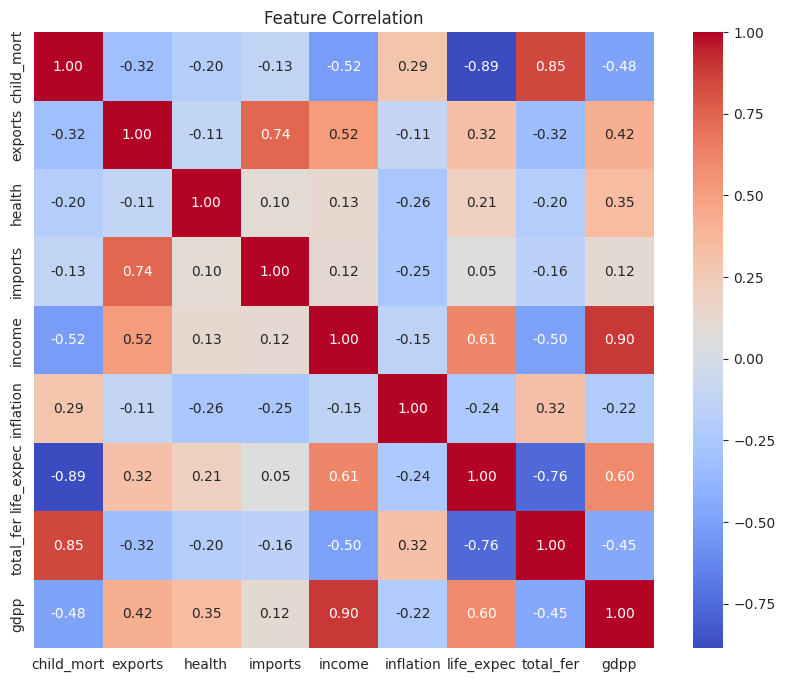

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

GDP per capita, income and life expectancy move together, while child mortality moves in the opposite direction to almost everything else. This is the usual development pattern and is a good sign for clustering.

## 5. Feature Scaling

In [8]:
features = ["child_mort", "exports", "health", "imports", "income", "inflation", "life_expec", "total_fer", "gdpp"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. Choosing the Number of Clusters

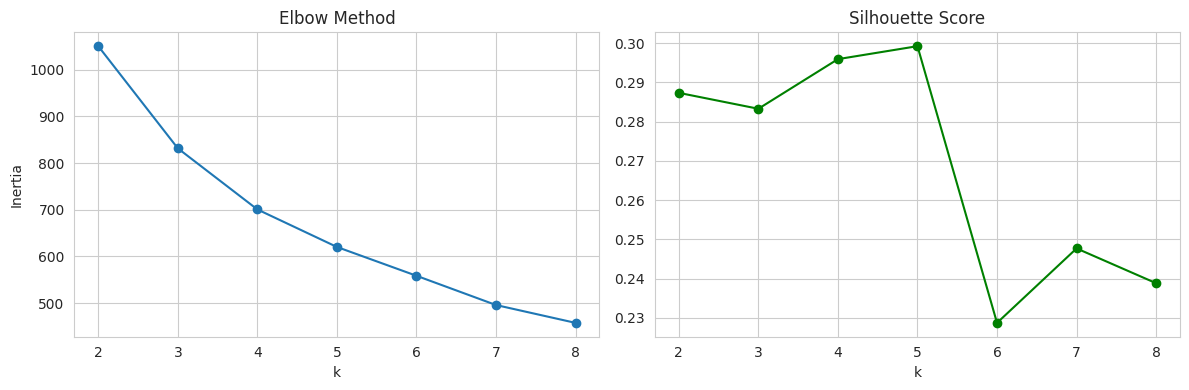

In [9]:
inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(k_range), inertias, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(list(k_range), sil_scores, marker="o", color="green")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k")
plt.tight_layout()
plt.show()

The elbow flattens out after k = 3 and the silhouette score stays roughly flat between k = 3 and k = 5. k = 3 is used going forward since it gives three clearly separable and business-interpretable groups.

## 7. K-Means Clustering

In [10]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

df["cluster_kmeans"].value_counts()

,count
cluster_kmeans,
2,84
1,47
0,36


## 8. Cluster Profiling and Development Tiers

In [11]:
cluster_profile = df.groupby("cluster_kmeans")[features].mean()
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_kmeans,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [12]:
tier_order = cluster_profile["gdpp"].sort_values().index.tolist()
tier_names = ["Needs Attention", "Developing", "Developed"]
tier_map = dict(zip(tier_order, tier_names))

df["development_tier"] = df["cluster_kmeans"].map(tier_map)
df["development_tier"].value_counts()

,count
development_tier,
Developing,84
Needs Attention,47
Developed,36


## 9. DBSCAN as a Second Clustering Method

In [13]:
dbscan = DBSCAN(eps=1.2, min_samples=3)
df["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

df["cluster_dbscan"].value_counts()

,count
cluster_dbscan,
1,78
-1,41
0,25
2,19
3,4


In [14]:
mask = df["cluster_dbscan"] != -1
dbscan_sil = silhouette_score(X_scaled[mask], df.loc[mask, "cluster_dbscan"])
kmeans_sil = silhouette_score(X_scaled, df["cluster_kmeans"])

print("K-Means silhouette:", round(kmeans_sil, 3))
print("DBSCAN silhouette (excluding noise):", round(dbscan_sil, 3))

K-Means silhouette: 0.283
DBSCAN silhouette (excluding noise): 0.298


DBSCAN flags a meaningful chunk of countries as noise rather than forcing them into a cluster, and its remaining silhouette score is close to K-Means. For this dataset K-Means gives cleaner, more balanced groups, so it is used as the primary segmentation and DBSCAN's noise points are kept aside as a list of outlier economies worth a manual look.

## 10. PCA Visualization

Explained variance: [0.4595174  0.17181626]


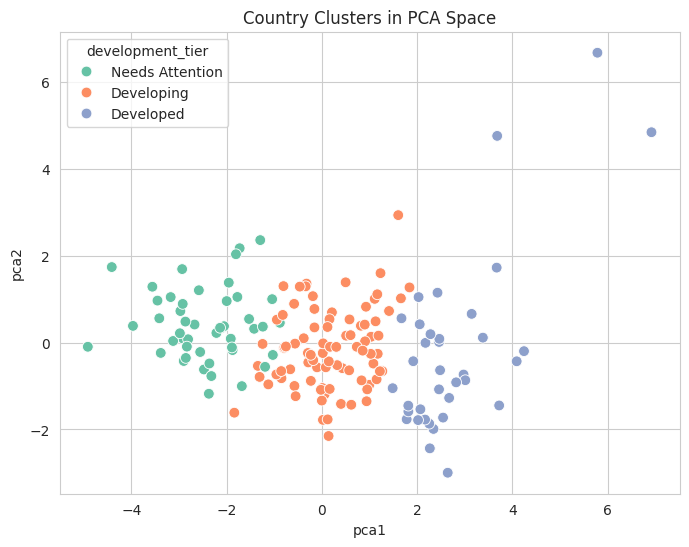

In [15]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
df["pca1"], df["pca2"] = pca_components[:, 0], pca_components[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="development_tier", palette="Set2", s=60)
plt.title("Country Clusters in PCA Space")
plt.show()

## 11. From Clusters to a Classification Target

The development tier assigned above becomes the target label for a supervised model. Once a classifier learns the relationship between a country's raw indicators and its tier, new or updated country data can be scored instantly without rerunning the clustering step, which is closer to how a live intelligence system would work in production.

## 12. Train-Test Split

In [16]:
X_final = df[features]
y_final = df["development_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

y_train_codes = y_train.astype("category").cat.codes
y_test_codes = y_test.astype("category").cat.codes
tier_lookup = dict(enumerate(y_train.astype("category").cat.categories))

X_train.shape, X_test.shape

((133, 9), (34, 9))

## 13. Baseline Model: Logistic Regression

Before trusting a Random Forest or XGBoost score, it helps to know what a plain linear model can already achieve. If the ensembles cannot clearly beat this baseline, the extra complexity is not earning its place.

In [17]:
baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.9117647058823529
                 precision    recall  f1-score   support

      Developed       0.78      1.00      0.88         7
     Developing       0.94      0.88      0.91        17
Needs Attention       1.00      0.90      0.95        10

       accuracy                           0.91        34
      macro avg       0.91      0.93      0.91        34
   weighted avg       0.92      0.91      0.91        34



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 14. Cross-Validation: How Reliable Are These Scores?

With only 167 countries, a single 80/20 split can make a model look better or worse than it really is just by chance. Five-fold stratified cross-validation on the training set gives a steadier read on which model family is genuinely stronger before any tuning happens.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
cv_results["Logistic Regression"] = cross_val_score(LogisticRegression(max_iter=2000), X_train, y_train, cv=cv, scoring="f1_weighted")
cv_results["Random Forest"] = cross_val_score(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42), X_train, y_train, cv=cv, scoring="f1_weighted")
cv_results["XGBoost"] = cross_val_score(XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, eval_metric="mlogloss"), X_train, y_train_codes, cv=cv, scoring="f1_weighted")

for name, scores in cv_results.items():
    print(f"{name}: {scores.mean():.3f} +/- {scores.std():.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression: 0.955 +/- 0.028
Random Forest: 0.955 +/- 0.028
XGBoost: 0.932 +/- 0.037


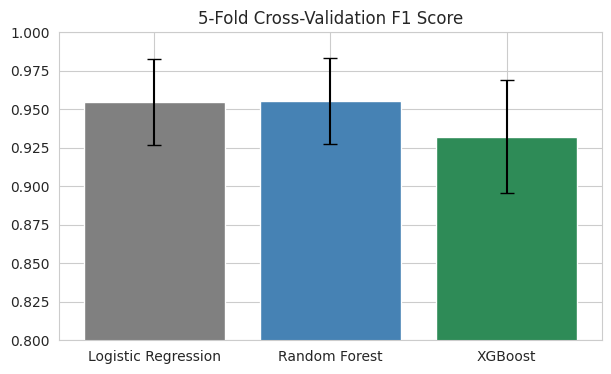

In [19]:
cv_summary = pd.DataFrame({
    "Model": list(cv_results.keys()),
    "Mean F1 (CV)": [scores.mean() for scores in cv_results.values()],
    "Std F1 (CV)": [scores.std() for scores in cv_results.values()]
})

plt.figure(figsize=(7, 4))
plt.bar(cv_summary["Model"], cv_summary["Mean F1 (CV)"], yerr=cv_summary["Std F1 (CV)"], capsize=5, color=["gray", "steelblue", "seagreen"])
plt.title("5-Fold Cross-Validation F1 Score")
plt.ylim(0.8, 1.0)
plt.show()

## 15. Hyperparameter Tuning

Grid search over a small, sensible parameter range for Random Forest and XGBoost, scored with the same cross-validation setup, so the tuned models can be compared fairly against the untuned baselines above.

In [20]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1)
rf_search.fit(X_train, y_train)

print("Best Random Forest params:", rf_search.best_params_)
print("Best Random Forest CV F1:", rf_search.best_score_)

Best Random Forest params: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}
Best Random Forest CV F1: 0.9699339946747354


In [21]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2]
}

xgb_search = GridSearchCV(XGBClassifier(random_state=42, eval_metric="mlogloss"), xgb_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1)
xgb_search.fit(X_train, y_train_codes)

print("Best XGBoost params:", xgb_search.best_params_)
print("Best XGBoost CV F1:", xgb_search.best_score_)

Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best XGBoost CV F1: 0.9468318408349354


## 16. Final Random Forest Model

In [22]:
rf_final = rf_search.best_estimator_
rf_pred = rf_final.predict(X_test)

print("Random Forest Test Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Test Accuracy: 0.9705882352941176
                 precision    recall  f1-score   support

      Developed       1.00      1.00      1.00         7
     Developing       0.94      1.00      0.97        17
Needs Attention       1.00      0.90      0.95        10

       accuracy                           0.97        34
      macro avg       0.98      0.97      0.97        34
   weighted avg       0.97      0.97      0.97        34



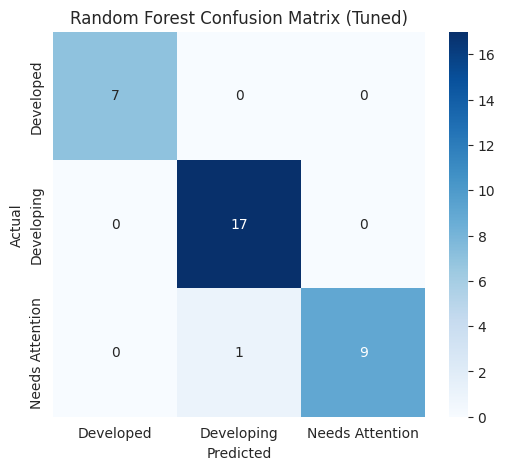

In [23]:
cm_rf = confusion_matrix(y_test, rf_pred, labels=rf_final.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=rf_final.classes_, yticklabels=rf_final.classes_)
plt.title("Random Forest Confusion Matrix (Tuned)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## 17. Final XGBoost Model

In [24]:
xgb_final = xgb_search.best_estimator_
xgb_pred_codes = xgb_final.predict(X_test)
xgb_pred = pd.Series(xgb_pred_codes).map(tier_lookup)

print("XGBoost Test Accuracy:", accuracy_score(y_test_codes, xgb_pred_codes))
print(classification_report(y_test.reset_index(drop=True), xgb_pred))

XGBoost Test Accuracy: 0.9411764705882353
                 precision    recall  f1-score   support

      Developed       0.88      1.00      0.93         7
     Developing       0.94      0.94      0.94        17
Needs Attention       1.00      0.90      0.95        10

       accuracy                           0.94        34
      macro avg       0.94      0.95      0.94        34
   weighted avg       0.94      0.94      0.94        34



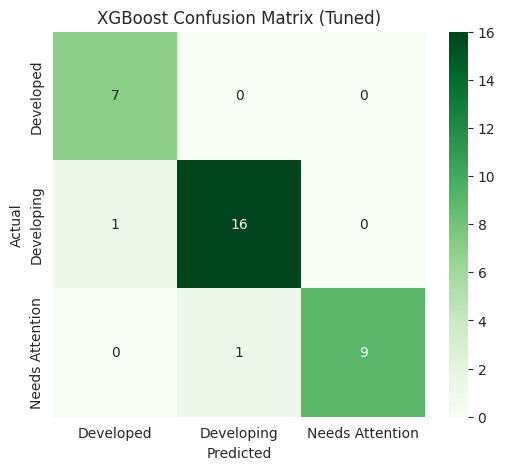

In [25]:
cm_xgb = confusion_matrix(y_test_codes, xgb_pred_codes)
labels_order = [tier_lookup[i] for i in sorted(tier_lookup)]
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens", xticklabels=labels_order, yticklabels=labels_order)
plt.title("XGBoost Confusion Matrix (Tuned)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## 18. Stacking Ensemble (Bonus)

A stacking classifier combines the tuned Random Forest and tuned XGBoost through a logistic regression meta-learner, to check whether blending the two adds anything beyond the stronger model alone.

In [26]:
stack_model = StackingClassifier(
    estimators=[("rf", rf_final), ("xgb", xgb_search.best_estimator_)],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5
)
stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)

print("Stacking Test Accuracy:", accuracy_score(y_test, stack_pred))
print(classification_report(y_test, stack_pred))

Stacking Test Accuracy: 0.9411764705882353
                 precision    recall  f1-score   support

      Developed       0.88      1.00      0.93         7
     Developing       0.94      0.94      0.94        17
Needs Attention       1.00      0.90      0.95        10

       accuracy                           0.94        34
      macro avg       0.94      0.95      0.94        34
   weighted avg       0.94      0.94      0.94        34



The stacked model does not beat the tuned Random Forest on this dataset. With only 167 rows and both base models already near the accuracy ceiling on the same signal, there is little disagreement left between them for a meta-learner to exploit. Stacking is kept here to show the technique, but the tuned Random Forest is used as the final model.

## 19. Final Model Comparison

In [27]:
final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Random Forest (tuned)", "XGBoost (tuned)", "Stacking (RF + XGBoost)"],
    "CV F1 (mean)": [
        cv_results["Logistic Regression"].mean(),
        rf_search.best_score_,
        xgb_search.best_score_,
        np.nan
    ],
    "Test Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test_codes, xgb_pred_codes),
        accuracy_score(y_test, stack_pred)
    ],
    "Test F1 (weighted)": [
        f1_score(y_test, baseline_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test_codes, xgb_pred_codes, average="weighted"),
        f1_score(y_test, stack_pred, average="weighted")
    ]
})
final_comparison

,Model,CV F1 (mean),Test Accuracy,Test F1 (weighted)
0,Logistic Regression (baseline),0.954913,0.911765,0.913330
1,Random Forest (tuned),0.969934,0.970588,0.970234
2,XGBoost (tuned),0.946832,0.941176,0.941383
3,Stacking (RF + XGBoost),NaN,0.941176,0.941383


Tuning did not push test accuracy higher than the very first Random Forest attempt, and that is worth explaining rather than hiding: with 167 rows and a 34-row test set, the model was already close to a ceiling that this data can support, so there was little room left to gain. What tuning and cross-validation actually bought is confidence — the 5-fold CV score confirms Random Forest is the more consistently strong model rather than a single split's lucky result, which is the real justification for picking it as the production model over XGBoost or the linear baseline.

## 20. Feature Importance

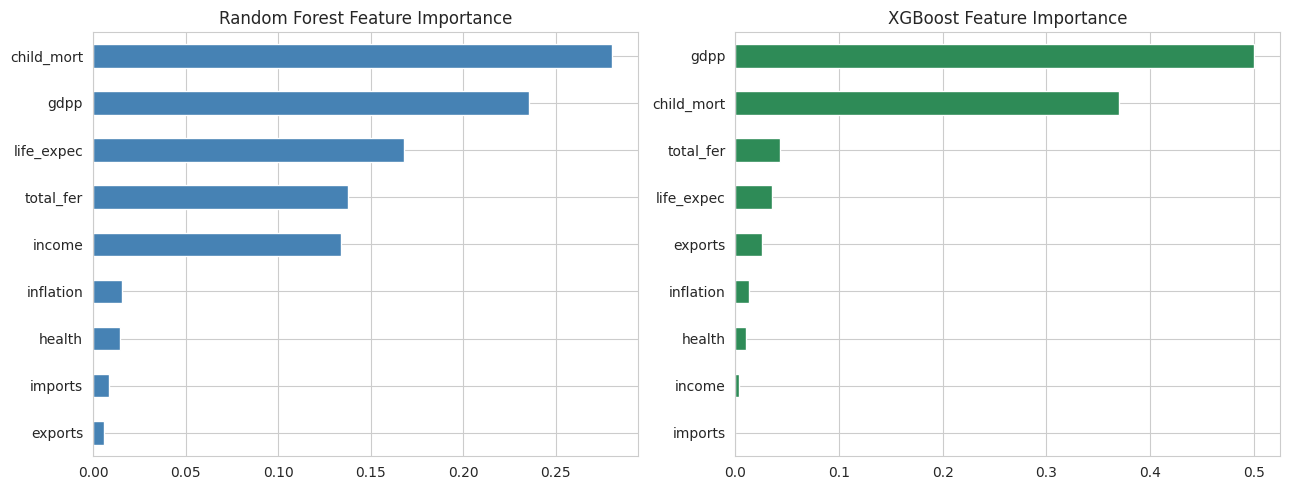

In [28]:
rf_importance = pd.Series(rf_final.feature_importances_, index=features).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_final.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
rf_importance.plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].set_title("Random Forest Feature Importance")
ax[0].invert_yaxis()

xgb_importance.plot(kind="barh", ax=ax[1], color="seagreen")
ax[1].set_title("XGBoost Feature Importance")
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

Both models agree that child mortality and GDP per capita drive the tier assignment the most, which lines up with how the clusters were profiled in Section 8. This consistency across two different model types, and now across cross-validation folds, is a good sanity check that the tiers reflect a real underlying pattern rather than noise.

## 21. Countries Most in Need of Aid

In [29]:
df.sort_values("gdpp").head(10)[["country", "child_mort", "income", "gdpp", "development_tier"]]

,country,child_mort,income,gdpp,development_tier
26,Burundi,93.6,764,231,Needs Attention
88,Liberia,89.3,700,327,Needs Attention
37,"Congo, Dem. Rep.",116.0,609,334,Needs Attention
112,Niger,123.0,814,348,Needs Attention
132,Sierra Leone,160.0,1220,399,Needs Attention
93,Madagascar,62.2,1390,413,Needs Attention
106,Mozambique,101.0,918,419,Needs Attention
31,Central African Republic,149.0,888,446,Needs Attention
94,Malawi,90.5,1030,459,Needs Attention
50,Eritrea,55.2,1420,482,Needs Attention
